# Crop Recommendation + Fertilizer Recommendation
## Final Year Project — Updated with ML-Based Fertilizer Model
### Part 1: Crop Classification | Part 2: Fertilizer NPK Regression

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.multioutput import MultiOutputRegressor

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## PART 1: Crop Recommendation (Classification)
---

In [2]:
# -------------------------------------------------------
# 1.1 Load Crop Recommendation Dataset
# -------------------------------------------------------
df = pd.read_csv('Crop_recommendation.csv')
X = df.drop('label', axis=1)
y = df['label']

print('Dataset Shape:', df.shape)
print('\nMissing Values:\n', df.isnull().sum())
print('\nColumns:', df.columns.tolist())
df.info()
df.head()

Dataset Shape: (2200, 8)

Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


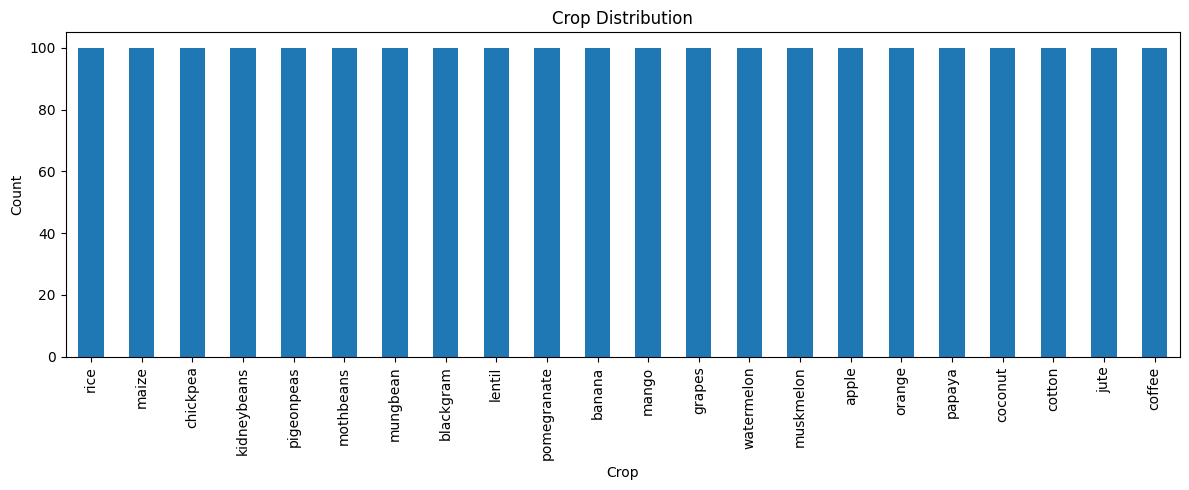

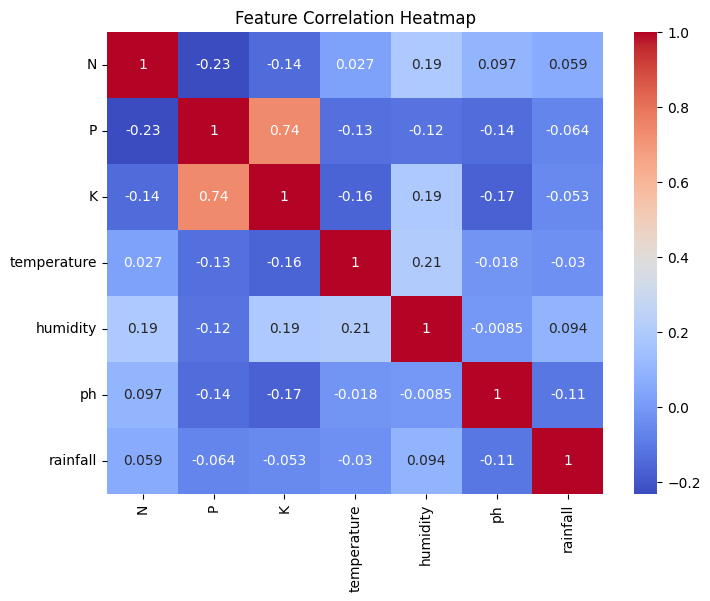

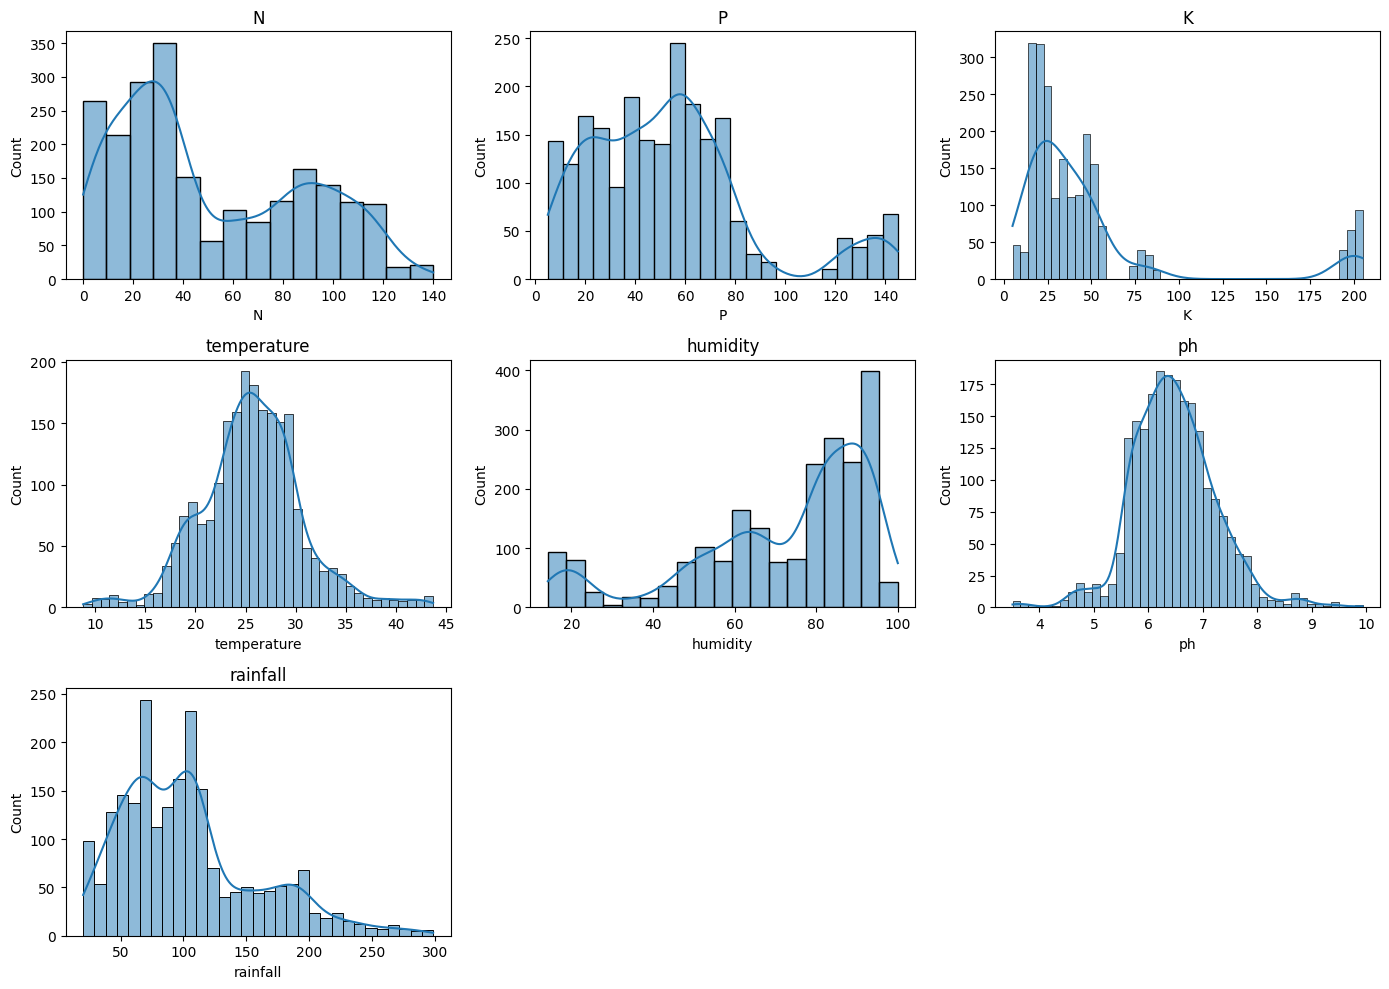

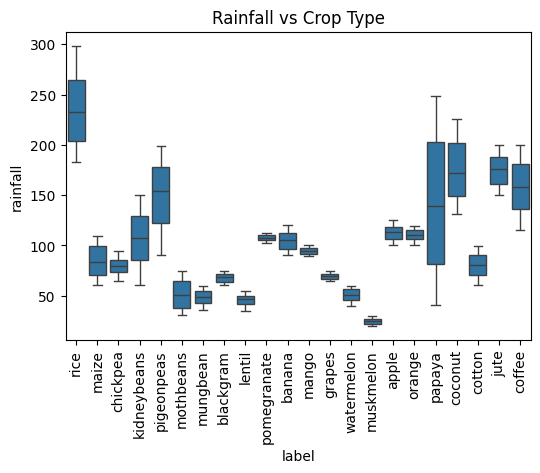

In [4]:
# -------------------------------------------------------
# 1.2 Exploratory Data Analysis
# -------------------------------------------------------
plt.figure(figsize=(12, 5))
df['label'].value_counts().plot(kind='bar')
plt.title('Crop Distribution')
plt.xlabel('Crop')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

features = df.columns[:-1]
plt.figure(figsize=(14, 10))
for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x='label', y='rainfall', data=df)
plt.xticks(rotation=90)
plt.title('Rainfall vs Crop Type')
plt.show()

In [5]:
# -------------------------------------------------------
# 1.3 Preprocessing — Scaling + Encoding
# -------------------------------------------------------
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)
print(f'Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}')

Training samples: 1540, Testing samples: 660


In [6]:
# -------------------------------------------------------
# 1.4 Train All Classification Models
# -------------------------------------------------------
models = {
    'Random Forest':    RandomForestClassifier(n_estimators=200, random_state=42),
    'Extra Trees':      ExtraTreesClassifier(n_estimators=200, random_state=42),
    'Decision Tree':    DecisionTreeClassifier(random_state=42),
    'KNN':              KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes':      GaussianNB(),
    'SVM':              SVC(kernel='rbf', probability=True),
    'Logistic Reg':     LogisticRegression(max_iter=1000, random_state=42)
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'Accuracy (%)': round(acc * 100, 2)}
    trained_models[name] = model

results_df = pd.DataFrame(results).T.sort_values(by='Accuracy (%)', ascending=False)
print('\n=== Model Accuracy Comparison ===')
print(results_df)


=== Model Accuracy Comparison ===
               Accuracy (%)
Random Forest         99.39
Extra Trees           99.39
Naive Bayes           99.24
SVM                   98.94
KNN                   98.03
Decision Tree         97.88
Logistic Reg          93.79


In [7]:
# -------------------------------------------------------
# 1.5 K-Fold Cross Validation
# -------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y_encoded, cv=skf, scoring='accuracy')
    cv_results[name] = round(scores.mean() * 100, 2)

cv_df = pd.DataFrame.from_dict(
    cv_results, orient='index', columns=['CV Accuracy (%)']
).sort_values(by='CV Accuracy (%)', ascending=False)

print('\n=== K-Fold Cross Validation Results ===')
print(cv_df)


=== K-Fold Cross Validation Results ===
               CV Accuracy (%)
Random Forest            99.59
Naive Bayes              99.45
Extra Trees              99.32
Decision Tree            98.77
SVM                      98.27
KNN                      97.82
Logistic Reg             94.05


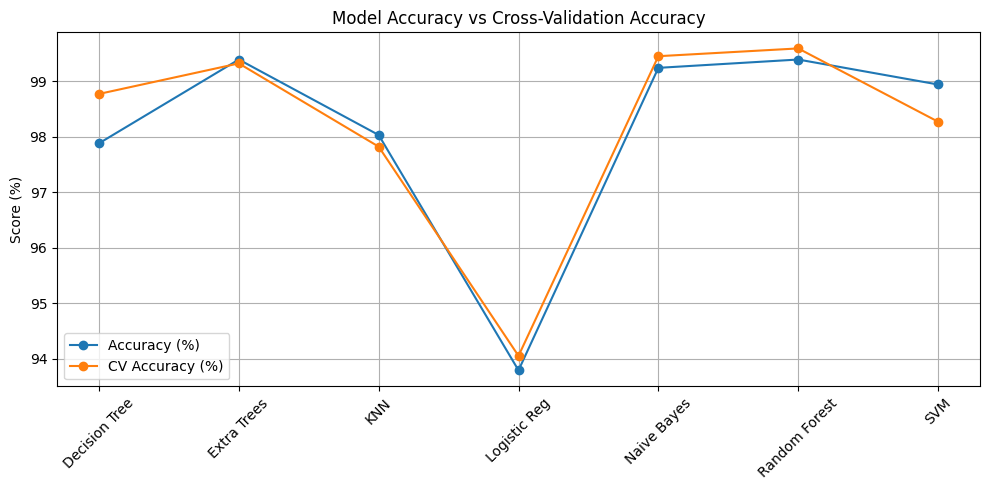

In [8]:
# -------------------------------------------------------
# 1.6 Accuracy vs Cross-Validation Comparison Plot
# -------------------------------------------------------
acc_series = results_df['Accuracy (%)']
cv_series  = pd.Series(cv_results)

compare_df = pd.DataFrame({
    'Accuracy (%)':    acc_series,
    'CV Accuracy (%)': cv_series
})

compare_df.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('Model Accuracy vs Cross-Validation Accuracy')
plt.ylabel('Score (%)')
plt.xticks(range(len(compare_df)), compare_df.index, rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

In [9]:
# -------------------------------------------------------
# 1.7 Select Best Model + Detailed Evaluation
# -------------------------------------------------------
best_model_name = results_df.index[0]
model = trained_models[best_model_name]
print(f'\nBest Model: {best_model_name}')

y_pred = model.predict(X_test)
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=le.classes_))


Best Model: Random Forest

=== Classification Report ===
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        30
      banana       1.00      1.00      1.00        30
   blackgram       1.00      0.97      0.98        30
    chickpea       1.00      1.00      1.00        30
     coconut       1.00      1.00      1.00        30
      coffee       1.00      1.00      1.00        30
      cotton       1.00      1.00      1.00        30
      grapes       1.00      1.00      1.00        30
        jute       0.94      1.00      0.97        30
 kidneybeans       1.00      1.00      1.00        30
      lentil       1.00      0.97      0.98        30
       maize       0.97      1.00      0.98        30
       mango       1.00      1.00      1.00        30
   mothbeans       0.97      1.00      0.98        30
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.00        30
      orange       1.00

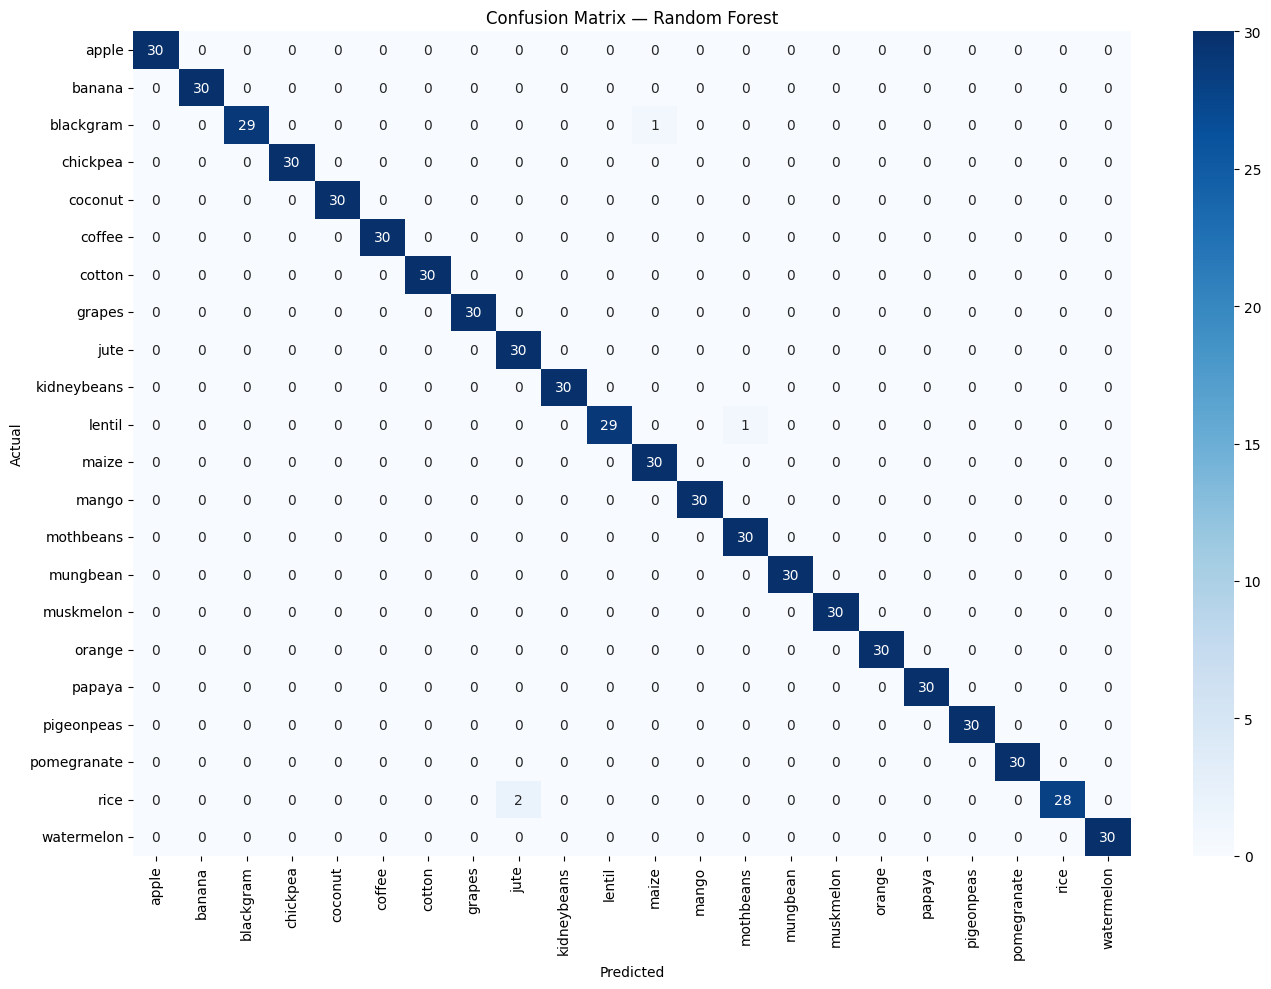

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title('Confusion Matrix — ' + best_model_name)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [11]:
# Precision, Recall, F1 for all models
all_metrics = {}
for name, mdl in trained_models.items():
    y_pred_m = mdl.predict(X_test)
    all_metrics[name] = {
        'Precision': round(precision_score(y_test, y_pred_m, average='weighted'), 4),
        'Recall':    round(recall_score(y_test, y_pred_m, average='weighted'), 4),
        'F1 Score':  round(f1_score(y_test, y_pred_m, average='weighted'), 4)
    }

metrics_df = pd.DataFrame(all_metrics).T
print('\n=== All Models — Precision, Recall, F1 Score ===')
print(metrics_df)


=== All Models — Precision, Recall, F1 Score ===
               Precision  Recall  F1 Score
Random Forest     0.9942  0.9939    0.9939
Extra Trees       0.9942  0.9939    0.9939
Decision Tree     0.9793  0.9788    0.9787
KNN               0.9812  0.9803    0.9803
Naive Bayes       0.9929  0.9924    0.9924
SVM               0.9906  0.9894    0.9893
Logistic Reg      0.9444  0.9379    0.9371


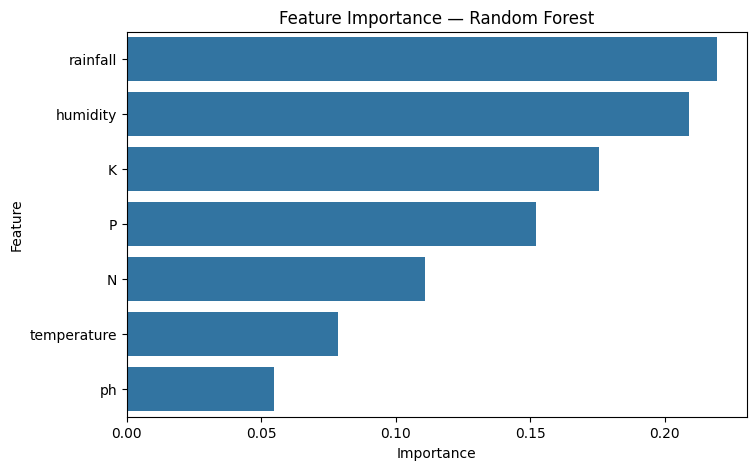

In [12]:
# -------------------------------------------------------
# 1.8 Feature Importance (Random Forest)
# -------------------------------------------------------
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

feat_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title('Feature Importance — Random Forest')
plt.show()

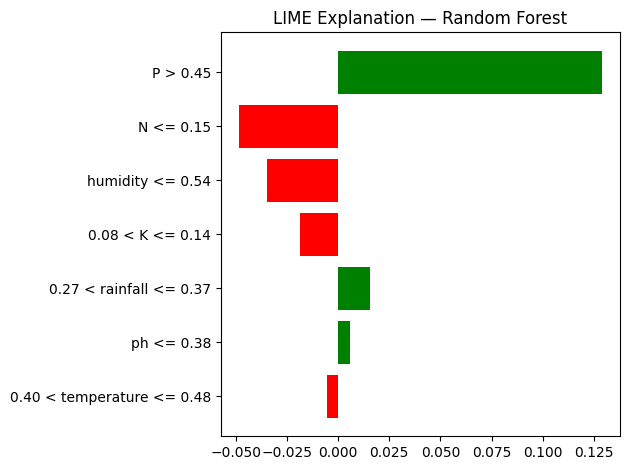

In [13]:
# -------------------------------------------------------
# 1.9 LIME Explanation
# -------------------------------------------------------
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns.tolist(),
    class_names=le.classes_.tolist(),
    mode='classification'
)

exp = explainer.explain_instance(
    X_test[0],
    model.predict_proba,
    num_features=7
)

exp.as_pyplot_figure()
plt.title('LIME Explanation — ' + best_model_name)
plt.tight_layout()
plt.show()

In [14]:
# -------------------------------------------------------
# 1.10 Crop Recommendation Function
# -------------------------------------------------------
def recommend_crop(N, P, K, temperature, humidity, ph, rainfall):
    input_data   = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    input_scaled = scaler.transform(input_data)
    pred_encoded = model.predict(input_scaled)
    return le.inverse_transform(pred_encoded)[0]

print('Crop recommendation function ready.')

Crop recommendation function ready.


---
## PART 2: Fertilizer Recommendation (ML Regression — Novel Contribution)
### This is the novelty added to the base paper.
### Inputs: Crop, Soil Type, Climate, Land Type
### Outputs: Recommended N, P, K values (kg/ha) — predicted by ML model
---

In [15]:
# -------------------------------------------------------
# 2.1 Load Fertilizer Dataset (self-created, corrected)
# -------------------------------------------------------
# Dataset covers 22 crops × 3 soil types × 3 climates × 4 land types = 792 records
# NPK values vary by all four input factors:
#   N varies with soil type, climate, and land type
#   P varies with soil type (sandy > loamy > clay due to retention differences)
#   K varies with climate and land type

fert_df = pd.read_csv('fertilizer_corrected.csv')

print('Fertilizer Dataset Shape:', fert_df.shape)
print('\nMissing Values:\n', fert_df.isnull().sum())
print('\nColumns:', fert_df.columns.tolist())
fert_df.head(10)

Fertilizer Dataset Shape: (792, 7)

Missing Values:
 Crop         0
Soil_Type    0
Climate      0
Land_Type    0
N            0
P            0
K            0
dtype: int64

Columns: ['Crop', 'Soil_Type', 'Climate', 'Land_Type', 'N', 'P', 'K']


,Crop,Soil_Type,Climate,Land_Type,N,P,K
0,rice,sandy,humid,irrigated,130,68,60
1,rice,sandy,humid,rainfed,120,68,58
2,rice,sandy,humid,dryland,120,68,56
3,rice,sandy,humid,upland,125,68,59
4,rice,sandy,dry,irrigated,130,68,65
5,rice,sandy,dry,rainfed,120,68,63
6,rice,sandy,dry,dryland,120,68,61
7,rice,sandy,dry,upland,125,68,64
8,rice,sandy,semi-arid,irrigated,130,68,63
9,rice,sandy,semi-arid,rainfed,120,68,61


In [16]:
fert_df.describe()

,N,P,K
count,792.000000,792.000000,792.000000
mean,86.780303,49.181818,50.462121
std,33.692665,13.164611,13.967312
min,20.000000,25.000000,26.000000
25%,60.000000,40.000000,39.000000
50%,90.000000,48.000000,49.000000
75%,110.000000,58.000000,61.000000
max,160.000000,78.000000,85.000000


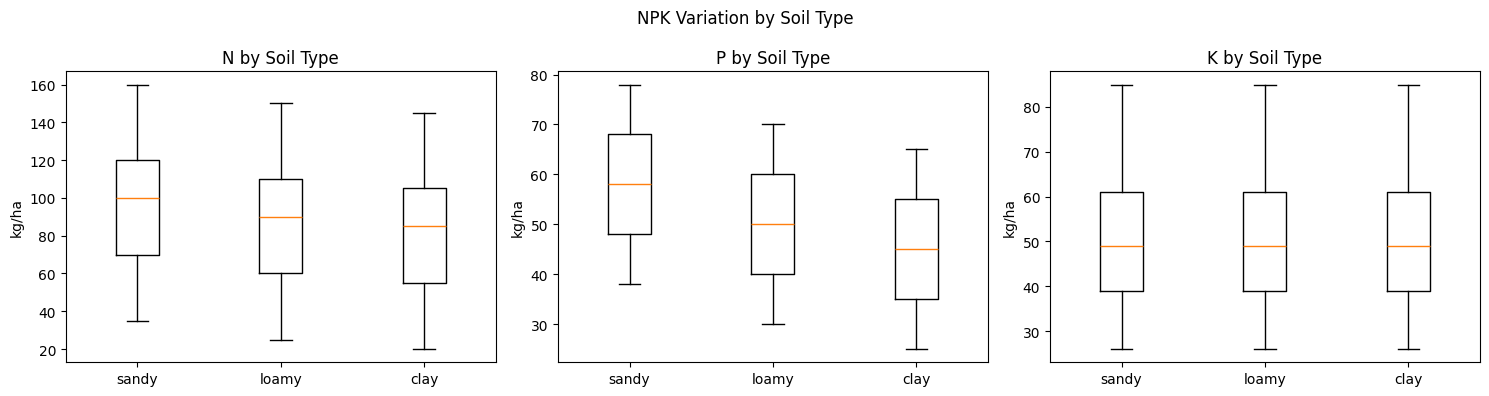

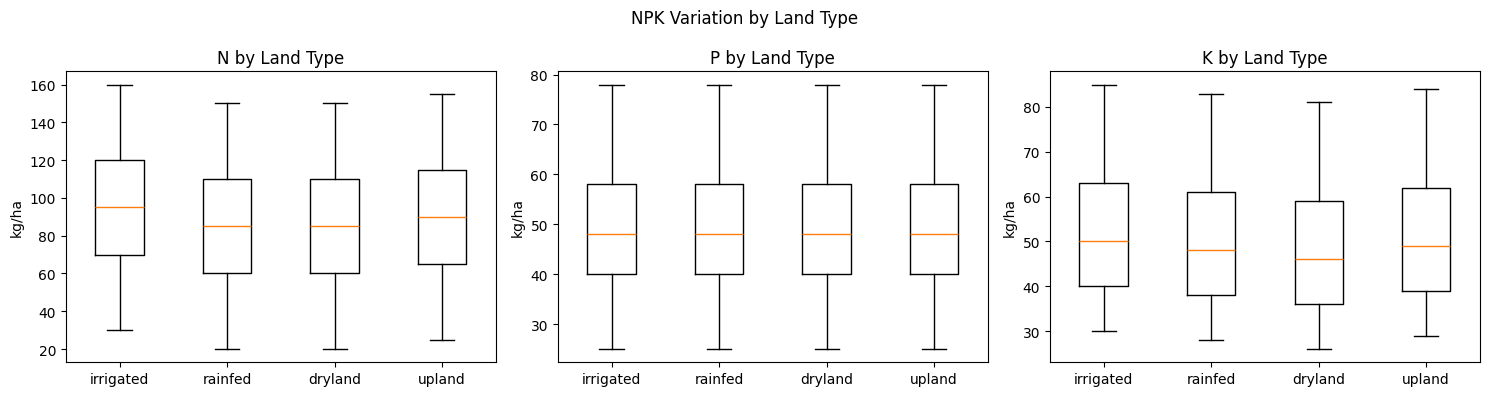

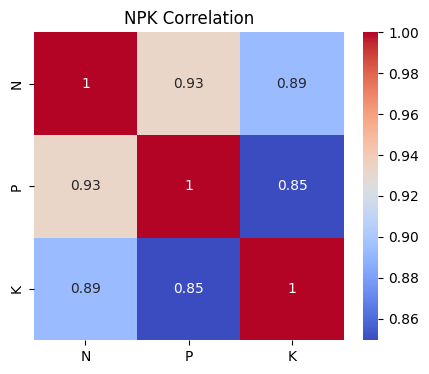

In [17]:
# -------------------------------------------------------
# 2.2 Fertilizer EDA
# -------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, nutrient in enumerate(['N', 'P', 'K']):
    axes[i].boxplot(
        [fert_df[fert_df['Soil_Type']==s][nutrient].values for s in ['sandy','loamy','clay']],
        labels=['sandy','loamy','clay']
    )
    axes[i].set_title(f'{nutrient} by Soil Type')
    axes[i].set_ylabel('kg/ha')
plt.suptitle('NPK Variation by Soil Type')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, nutrient in enumerate(['N', 'P', 'K']):
    axes[i].boxplot(
        [fert_df[fert_df['Land_Type']==l][nutrient].values
         for l in ['irrigated','rainfed','dryland','upland']],
        labels=['irrigated','rainfed','dryland','upland']
    )
    axes[i].set_title(f'{nutrient} by Land Type')
    axes[i].set_ylabel('kg/ha')
plt.suptitle('NPK Variation by Land Type')
plt.tight_layout()
plt.show()

# Correlation heatmap for fertilizer dataset (numeric columns)
plt.figure(figsize=(5, 4))
sns.heatmap(fert_df[['N','P','K']].corr(), annot=True, cmap='coolwarm')
plt.title('NPK Correlation')
plt.show()

In [18]:
# -------------------------------------------------------
# 2.3 Preprocessing — Label Encoding for Categoricals
# -------------------------------------------------------
le_crop    = LabelEncoder()
le_soil    = LabelEncoder()
le_climate = LabelEncoder()
le_land    = LabelEncoder()

fert_enc = fert_df.copy()
fert_enc['Crop_enc']    = le_crop.fit_transform(fert_df['Crop'])
fert_enc['Soil_enc']    = le_soil.fit_transform(fert_df['Soil_Type'])
fert_enc['Climate_enc'] = le_climate.fit_transform(fert_df['Climate'])
fert_enc['Land_enc']    = le_land.fit_transform(fert_df['Land_Type'])

X_fert = fert_enc[['Crop_enc', 'Soil_enc', 'Climate_enc', 'Land_enc']].values
y_fert = fert_enc[['N', 'P', 'K']].values   # multi-output target

X_fert_train, X_fert_test, y_fert_train, y_fert_test = train_test_split(
    X_fert, y_fert, test_size=0.2, random_state=42
)

print(f'Training samples: {X_fert_train.shape[0]}, Testing samples: {X_fert_test.shape[0]}')
print('Encoded classes:')
print('  Crops   :', le_crop.classes_)
print('  Soil    :', le_soil.classes_)
print('  Climate :', le_climate.classes_)
print('  Land    :', le_land.classes_)

Training samples: 633, Testing samples: 159
Encoded classes:
  Crops   : ['banana' 'barley' 'chickpea' 'coconut' 'coffee' 'cotton' 'groundnut'
 'lentil' 'maize' 'millet' 'mustard' 'onion' 'pea' 'potato' 'rice'
 'sorghum' 'soybean' 'sugarcane' 'sunflower' 'tea' 'tomato' 'wheat']
  Soil    : ['clay' 'loamy' 'sandy']
  Climate : ['dry' 'humid' 'semi-arid']
  Land    : ['dryland' 'irrigated' 'rainfed' 'upland']


In [19]:
# -------------------------------------------------------
# 2.4 Multi-Output Regression — Multiple Models Compared
# -------------------------------------------------------
# MultiOutputRegressor wraps a base regressor to predict
# all three targets (N, P, K) simultaneously.
# This is the ML novelty: instead of a lookup table,
# we learn the NPK mapping from data.

from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

fert_regressors = {
    'Random Forest':   MultiOutputRegressor(RandomForestRegressor(n_estimators=200, random_state=42)),
    'Decision Tree':   MultiOutputRegressor(DecisionTreeRegressor(random_state=42)),
    'KNN Regressor':   MultiOutputRegressor(KNeighborsRegressor(n_neighbors=5)),
    'SVR':             MultiOutputRegressor(SVR(kernel='rbf', C=10, epsilon=0.1)),
}

reg_results = {}
trained_regressors = {}

for name, reg in fert_regressors.items():
    reg.fit(X_fert_train, y_fert_train)
    y_pred_r = reg.predict(X_fert_test)

    mae_N = mean_absolute_error(y_fert_test[:, 0], y_pred_r[:, 0])
    mae_P = mean_absolute_error(y_fert_test[:, 1], y_pred_r[:, 1])
    mae_K = mean_absolute_error(y_fert_test[:, 2], y_pred_r[:, 2])
    r2_N  = r2_score(y_fert_test[:, 0], y_pred_r[:, 0])
    r2_P  = r2_score(y_fert_test[:, 1], y_pred_r[:, 1])
    r2_K  = r2_score(y_fert_test[:, 2], y_pred_r[:, 2])

    reg_results[name] = {
        'MAE_N': round(mae_N, 3), 'MAE_P': round(mae_P, 3), 'MAE_K': round(mae_K, 3),
        'R2_N':  round(r2_N, 4),  'R2_P':  round(r2_P, 4),  'R2_K':  round(r2_K, 4),
        'Mean R2': round((r2_N + r2_P + r2_K) / 3, 4)
    }
    trained_regressors[name] = reg

reg_df = pd.DataFrame(reg_results).T.sort_values(by='Mean R2', ascending=False)
print('\n=== Fertilizer Regressor Comparison ===')
print(reg_df.to_string())


=== Fertilizer Regressor Comparison ===
                MAE_N  MAE_P   MAE_K    R2_N    R2_P    R2_K  Mean R2
Decision Tree   0.692  0.000   0.151  0.9943  1.0000  0.9968   0.9970
Random Forest   2.127  0.055   0.522  0.9935  0.9999  0.9970   0.9968
KNN Regressor  11.774  4.462   5.247  0.8005  0.7935  0.7483   0.7808
SVR            25.439  8.724  10.569  0.1982  0.3144  0.1081   0.2069


In [21]:
# -------------------------------------------------------
# 2.5 K-Fold Cross-Validation on Best Regressor
# -------------------------------------------------------
best_reg_name = reg_df.index[0]
best_reg = trained_regressors[best_reg_name]
print(f'Best Fertilizer Regressor: {best_reg_name}')

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# MultiOutputRegressor needs the full 2D y_fert (all 3 columns together)
# We manually split and compute R2 per nutrient from each fold
from sklearn.model_selection import KFold
from sklearn.base import clone

n_fold_r2 = {'N': [], 'P': [], 'K': []}

for train_idx, test_idx in kf.split(X_fert):
    X_tr, X_te = X_fert[train_idx], X_fert[test_idx]
    y_tr, y_te = y_fert[train_idx], y_fert[test_idx]

    fold_model = clone(best_reg)
    fold_model.fit(X_tr, y_tr)
    y_fold_pred = fold_model.predict(X_te)

    for i, nutrient in enumerate(['N', 'P', 'K']):
        r2 = r2_score(y_te[:, i], y_fold_pred[:, i])
        n_fold_r2[nutrient].append(r2)

print('\n=== 5-Fold Cross-Validation R2 Scores ===')
for nutrient, scores in n_fold_r2.items():
    scores_arr = np.array(scores)
    print(f'  {nutrient} — CV R2: {scores_arr.mean():.4f} (+/- {scores_arr.std():.4f})')

Best Fertilizer Regressor: Decision Tree

=== 5-Fold Cross-Validation R2 Scores ===
  N — CV R2: 0.9958 (+/- 0.0020)
  P — CV R2: 1.0000 (+/- 0.0000)
  K — CV R2: 0.9982 (+/- 0.0009)


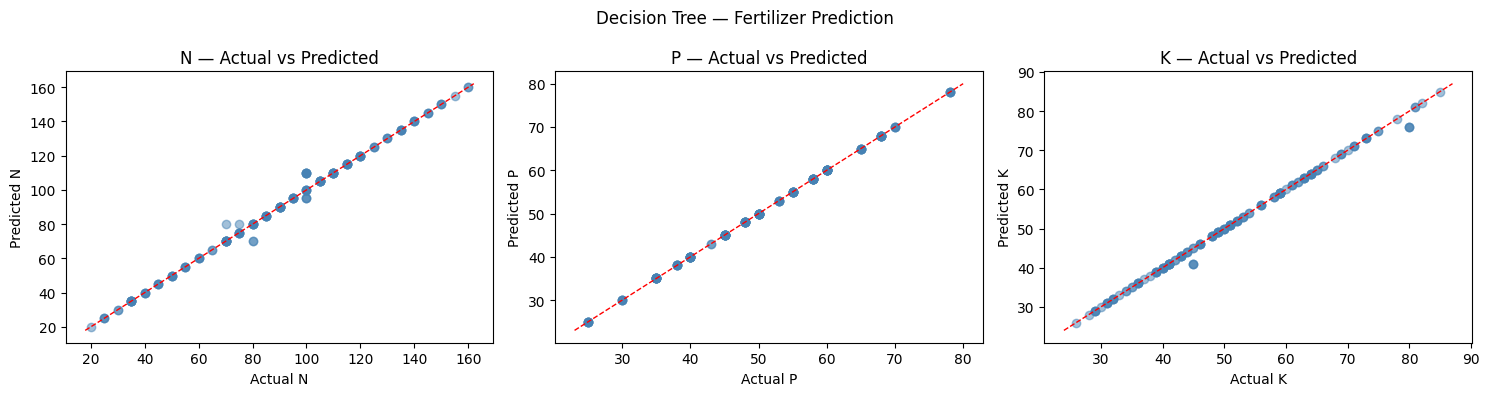

In [22]:
# -------------------------------------------------------
# 2.6 Actual vs Predicted Plot
# -------------------------------------------------------
y_pred_best = best_reg.predict(X_fert_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, nutrient in enumerate(['N', 'P', 'K']):
    axes[i].scatter(y_fert_test[:, i], y_pred_best[:, i], alpha=0.5, color='steelblue')
    lim = [min(y_fert_test[:, i].min(), y_pred_best[:, i].min()) - 2,
           max(y_fert_test[:, i].max(), y_pred_best[:, i].max()) + 2]
    axes[i].plot(lim, lim, 'r--', linewidth=1)
    axes[i].set_xlabel(f'Actual {nutrient}')
    axes[i].set_ylabel(f'Predicted {nutrient}')
    axes[i].set_title(f'{nutrient} — Actual vs Predicted')
plt.suptitle(f'{best_reg_name} — Fertilizer Prediction')
plt.tight_layout()
plt.show()

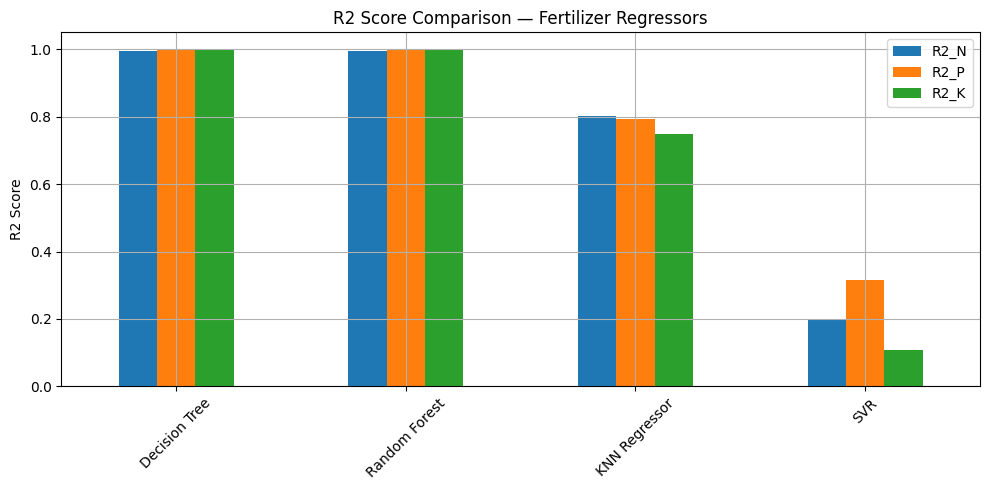

In [23]:
# Regressor R2 comparison bar plot
reg_df[['R2_N', 'R2_P', 'R2_K']].plot(kind='bar', figsize=(10, 5))
plt.title('R2 Score Comparison — Fertilizer Regressors')
plt.ylabel('R2 Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

In [24]:
# -------------------------------------------------------
# 2.7 ML-Based Fertilizer Recommendation Function
# -------------------------------------------------------
def get_recommended_npk_ml(crop, soil, climate, land):
    """
    Predict recommended N, P, K (kg/ha) using the trained
    MultiOutputRegressor model.

    Parameters:
        crop    : str  e.g. 'rice'
        soil    : str  'sandy' | 'loamy' | 'clay'
        climate : str  'humid' | 'dry' | 'semi-arid'
        land    : str  'irrigated' | 'rainfed' | 'dryland' | 'upland'

    Returns:
        (rec_N, rec_P, rec_K) as rounded integers
    """
    try:
        c  = le_crop.transform([crop.lower()])[0]
        s  = le_soil.transform([soil.lower()])[0]
        cl = le_climate.transform([climate.lower()])[0]
        l  = le_land.transform([land.lower()])[0]
    except ValueError as e:
        print(f'Invalid input: {e}')
        return None

    pred = best_reg.predict([[c, s, cl, l]])[0]
    return round(pred[0]), round(pred[1]), round(pred[2])


print('ML fertilizer recommendation function ready.')
print('\nTest: rice / sandy / humid / irrigated')
print('Predicted:', get_recommended_npk_ml('rice', 'sandy', 'humid', 'irrigated'))

ML fertilizer recommendation function ready.

Test: rice / sandy / humid / irrigated
Predicted: (130, 68, 60)


---
## PART 3: End-to-End Pipeline
### Step 1 → Predict crop from soil/weather parameters
### Step 2 → Predict recommended NPK for that crop using ML
### Step 3 → Calculate soil deficiency
### Step 4 → Calculate fertilizer dosage (Urea / DAP / MOP)
---

In [25]:
# -------------------------------------------------------
# 3.1 Helper Functions
# -------------------------------------------------------
def calculate_deficiency(rec_N, rec_P, rec_K, soil_N, soil_P, soil_K):
    """Returns how much extra N, P, K is needed above current soil level."""
    N_def = max(rec_N - soil_N, 0)
    P_def = max(rec_P - soil_P, 0)
    K_def = max(rec_K - soil_K, 0)
    return N_def, P_def, K_def


def fertilizer_dosage(N_def, P_def, K_def):
    """
    Convert NPK deficiency to commercial fertilizer kg/acre.
      Urea  (46% N) : urea_kg  = N_def / 0.46
      DAP   (46% P) : dap_kg   = P_def / 0.46
      MOP   (60% K) : mop_kg   = K_def / 0.60
    """
    urea = round(N_def / 0.46, 2)
    dap  = round(P_def / 0.46, 2)
    mop  = round(K_def / 0.60, 2)
    return urea, dap, mop


print('Helper functions ready.')

Helper functions ready.


In [28]:
# -------------------------------------------------------
# 3.2 Run End-to-End Pipeline
# -------------------------------------------------------
print('=' * 50)
print('   CROP & FERTILIZER RECOMMENDATION SYSTEM')
print('=' * 50)

# --- Step 1: Crop Recommendation Inputs ---
print('\n--- Step 1: Enter Soil & Weather Parameters ---')
N_input       = float(input('Nitrogen in soil (N kg/ha): '))
P_input       = float(input('Phosphorus in soil (P kg/ha): '))
K_input       = float(input('Potassium in soil (K kg/ha): '))
temperature   = float(input('Temperature (°C): '))
humidity      = float(input('Humidity (%): '))
ph            = float(input('Soil pH: '))
rainfall      = float(input('Rainfall (mm): '))

# --- Step 2: Predict Crop ---
predicted_crop = recommend_crop(N_input, P_input, K_input, temperature, humidity, ph, rainfall)
print(f'\n Recommended Crop: {predicted_crop.upper()}')

# --- Step 3: Environmental Details for Fertilizer ---
print('\n--- Step 2: Enter Environmental Details ---')
soil_type = input('Soil Type (sandy / loamy / clay): ').strip().lower()
climate   = input('Climate (humid / dry / semi-arid): ').strip().lower()
land_type = input('Land Type (irrigated / rainfed / dryland / upland): ').strip().lower()

# --- Step 4: ML-Based NPK Recommendation ---
npk = get_recommended_npk_ml(predicted_crop, soil_type, climate, land_type)
if npk is None:
    print('Could not retrieve NPK. Check input values.')
else:
    rec_N, rec_P, rec_K = npk
    print(f'\n Recommended NPK (from ML model):')
    print(f'   N = {rec_N} kg/ha   P = {rec_P} kg/ha   K = {rec_K} kg/ha')

    # --- Step 5: Deficiency ---
    N_def, P_def, K_def = calculate_deficiency(rec_N, rec_P, rec_K, N_input, P_input, K_input)
    print(f'\n Soil Nutrient Deficiency (additional requirement):')
    print(f'   Nitrogen needed  : {N_def} kg/ha')
    print(f'   Phosphorus needed: {P_def} kg/ha')
    print(f'   Potassium needed : {K_def} kg/ha')

    # --- Step 6: Fertilizer Dosage ---
    urea, dap, mop = fertilizer_dosage(N_def, P_def, K_def)
    print(f'\n Recommended Fertilizer Dosage (per acre):')
    print(f'   Urea (46% N) : {urea} kg/acre')
    print(f'   DAP  (46% P) : {dap} kg/acre')
    print(f'   MOP  (60% K) : {mop} kg/acre')

   CROP & FERTILIZER RECOMMENDATION SYSTEM

--- Step 1: Enter Soil & Weather Parameters ---


Nitrogen in soil (N kg/ha):  90
Phosphorus in soil (P kg/ha):  42
Potassium in soil (K kg/ha):  43
Temperature (°C):  20.8
Humidity (%):  82.004
Soil pH:  6.5
Rainfall (mm):  202.9



 Recommended Crop: RICE

--- Step 2: Enter Environmental Details ---


Soil Type (sandy / loamy / clay):  clay
Climate (humid / dry / semi-arid):  semi-arid
Land Type (irrigated / rainfed / dryland / upland):  irrigated



 Recommended NPK (from ML model):
   N = 115 kg/ha   P = 55 kg/ha   K = 63 kg/ha

 Soil Nutrient Deficiency (additional requirement):
   Nitrogen needed  : 25.0 kg/ha
   Phosphorus needed: 13.0 kg/ha
   Potassium needed : 20.0 kg/ha

 Recommended Fertilizer Dosage (per acre):
   Urea (46% N) : 54.35 kg/acre
   DAP  (46% P) : 28.26 kg/acre
   MOP  (60% K) : 33.33 kg/acre
